#### Illustration of the lakes in hma region.     

In [ ]:
import warnings
import pandas as pd
import numpy as np
import geopandas as gpd
import rasterio as rio
from PIL import Image 
import cartopy.crs as ccrs
from utils.imgShow import imgShow
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
from pyrsimg import add_north_arrow, add_scale_bar
warnings.filterwarnings("ignore")


In [7]:
### define dem cmap
# colors = [(128/255, 205/255, 193/255), 
#           (245/255, 245/255, 245/255),
#           (223/255, 194/255, 125/255), 
#           (166/255, 97/255, 26/255)]
colors = [
    # (65/255, 105/255, 225/255),   # 深湖蓝 (<3000m)
    (173/255, 216/255, 230/255),  # 淡蓝色 (<3000m)
    (230/255, 220/255, 170/255),  # 草甸金 (3000-4000m)
    (210/255, 180/255, 140/255),  # 荒漠黄 (4000-4800m)
    (185/255, 150/255, 120/255),  # 丘陵棕 (4800-5200m)
    (150/255, 120/255, 100/255),  # 山地褐 (5200-5500m)
    (180/255, 175/255, 170/255),  # 裸岩灰 (5500-5800m)
    (210/255, 210/255, 210/255),  # 积雪灰 (5800-6200m)
    (245/255, 245/255, 245/255)   # 冰川白 (>6200m)
]
cmap_dem = LinearSegmentedColormap.from_list('linear color', colors)

In [8]:
path_srtm = 'data/dem/hma_SRTMGL3_500m.tif'
path_hma_gtng = 'data/hma-extent/HMA/hma_gtng_202307_fill.gpkg'
path_lakes = 'data/water-extent/lakes/sui2025_hma_lakes/hma_lakes_2019_2023.gpkg'
path_rivers = 'data/water-extent/rivers/hma_major_rivers.gpkg' 


In [9]:
hma_vec_gdf = gpd.read_file(path_hma_gtng)
hma_lakes_gdf = gpd.read_file(path_lakes)
hma_rivers_gdf = gpd.read_file(path_rivers)
with rio.open(path_srtm) as dem_rio:
    dem_meta = dem_rio.meta
    dem_bounds = dem_rio.bounds
    dem_arr = dem_rio.read(1)
dem_extent = [dem_bounds.left, dem_bounds.right, dem_bounds.bottom, dem_bounds.top]


In [10]:
hma_lakes_larger10_gdf = hma_lakes_gdf[hma_lakes_gdf['area'] > 10]
hma_lakes_1_10_gdf = hma_lakes_gdf[(hma_lakes_gdf['area'] > 1) & (hma_lakes_gdf['area'] <= 10)]
hma_lakes_smaller1_gdf = hma_lakes_gdf[hma_lakes_gdf['area'] <= 1]
print(hma_lakes_larger10_gdf.shape)
print(hma_lakes_1_10_gdf.shape)
print(hma_lakes_smaller1_gdf.shape)


(500, 18)
(1289, 18)
(449988, 18)


In [11]:
print(hma_lakes_larger10_gdf['area'].sum())
print(hma_lakes_1_10_gdf['area'].sum())
print(hma_lakes_smaller1_gdf['area'].sum())


69327.62208812
3767.0929399710003
5315.056379853299


In [12]:
hma_lakes_larger10_center = hma_lakes_larger10_gdf.geometry.centroid
hma_lakes_1_10_center = hma_lakes_1_10_gdf.geometry.centroid
hma_lakes_smaller1_center = hma_lakes_smaller1_gdf.geometry.centroid


Text(0.5, 1.0, 'HMA DEM')

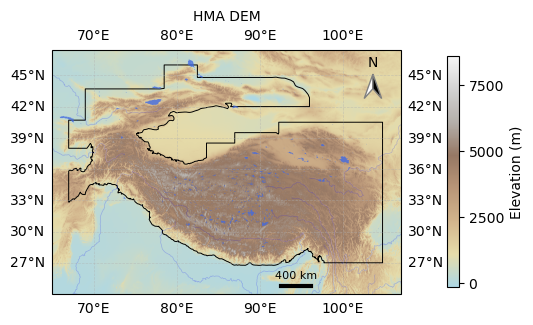

In [13]:
fig, ax = plt.subplots(figsize=(6, 6), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([65,107,24,45.5])
im_show = ax.imshow(dem_arr, cmap=cmap_dem, extent=dem_extent)
fig.colorbar(im_show, ax=ax, orientation='vertical',pad=0.1,
                    label='Elevation (m)', shrink=0.5,
                    ticks=[0, 2500, 5000, 7500])
hma_vec_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.7)
hma_rivers_gdf.plot(ax=ax, color='blue', linewidth=0.5, alpha=0.2) 
hma_lakes_larger10_gdf.plot(ax=ax, facecolor='#4169E1', alpha=0.8, zorder=5)
# hma_lakes_1_10_center.plot(ax=ax, marker='o', 
#                            color='brown', markersize=0.1, alpha=0.3)
# hma_lakes_smaller1_center.plot(ax=ax, marker='o', 
#                                color='red', markersize=0.1, alpha=0.3)
ax.gridlines(draw_labels=True, linestyle='--', linewidth=0.5, alpha=0.5)
add_north_arrow(ax, size=(0.05, 0.05), loc=(0.92, 0.85), font_N=10)
add_scale_bar(ax, loc=(0.7, 0.03), length=400, fontsize=8)
ax.set_title('HMA DEM', fontsize=10)
# fig.savefig('figures/dem/hma_dem.png', dpi=300, bbox_inches='tight')



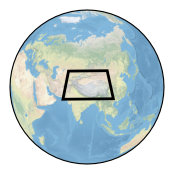

In [22]:
basemap = Image.open('data/basemap/natural-earth-1_large4096px.png')
fig, ax = plt.subplots(figsize=(2, 2), 
            subplot_kw={'projection': ccrs.Orthographic(central_longitude=85, central_latitude=35)})

ax.imshow(basemap, extent=[-180, 180, -90, 90], transform=ccrs.PlateCarree()) 

hma_extent = [65, 107, 24, 45.5]
hma_poly = Rectangle(
    (hma_extent[0], hma_extent[2]),  hma_extent[1]-hma_extent[0], 
    hma_extent[3]-hma_extent[2], linewidth=2, 
    edgecolor="#000000",  #
    facecolor='none', alpha=1,
    transform=ccrs.PlateCarree(),zorder=6)
ax.add_patch(hma_poly)


In [103]:
### remote sensing image show 
path_region_1 = 'data/water-extent/lakes/rsimg_site/l8_20240825.tif'
path_region_2 = 'data/water-extent/lakes/rsimg_site/l8_20250705.tif'
path_region_3 = 'data/water-extent/lakes/rsimg_site/l9_20240913.tif'
path_region_4 = 'data/water-extent/lakes/rsimg_site/s2_20240929.tif'
path_region_5 = 'data/water-extent/lakes/rsimg_site/s2_20250812.tif'
path_lakes_sel = 'data/water-extent/lakes/rsimg_site/hma_lakes_2019_2023_select.gpkg'


In [104]:
hma_lakes_sel_gdf = gpd.read_file(path_lakes_sel)
hma_lakes_sel_larger10_gdf = hma_lakes_sel_gdf[hma_lakes_sel_gdf['area'] > 10]
hma_lakes_sel_1_10_gdf = hma_lakes_sel_gdf[(hma_lakes_sel_gdf['area'] > 1) & (hma_lakes_sel_gdf['area'] <= 10)]
hma_lakes_sel_smaller1_gdf = hma_lakes_sel_gdf[hma_lakes_sel_gdf['area'] <= 1]


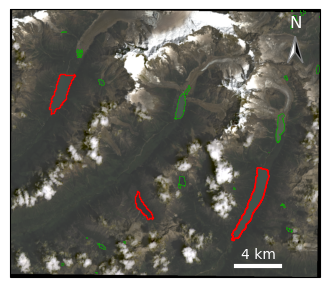

In [140]:
region_1_rio = rio.open(path_region_1)
region_1_bounds = region_1_rio.bounds
region_1_extent = [region_1_bounds.left, region_1_bounds.right, region_1_bounds.bottom, region_1_bounds.top]
fig, ax_1 = plt.subplots(figsize=(4, 4), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax_1.set_extent(region_1_extent)
imgShow(region_1_rio.read().transpose(1, 2, 0), 
                color_bands=[2,1,0], 
                per_band_clip=10, 
                extent=region_1_extent, ax=ax_1)
hma_lakes_sel_smaller1_gdf.plot(ax=ax_1, facecolor='none', 
                            edgecolor="#169C0A", linewidth=0.5)
hma_lakes_sel_1_10_gdf.plot(ax=ax_1, facecolor='none', 
                            edgecolor="#FD0000", linewidth=1)
add_scale_bar(ax_1, loc=(0.8, 0.04), color_bar='white', color_text='white', length=4)
add_north_arrow(ax_1, size=(0.05, 0.05), loc=(0.92, 0.85), color_N='white')


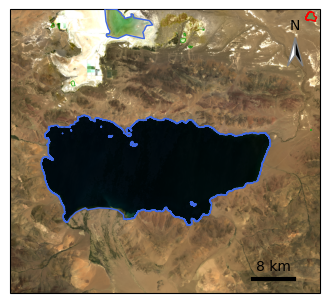

In [144]:
region_2_rio = rio.open(path_region_2)
region_2_bounds = region_2_rio.bounds
region_2_extent = [region_2_bounds.left, region_2_bounds.right, 
                   region_2_bounds.bottom, region_2_bounds.top]
fig, ax_2 = plt.subplots(figsize=(4, 4), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax_2.set_extent([83.87, 84.42, 30.95, 31.37])
imgShow(region_2_rio.read().transpose(1, 2, 0), 
                color_bands=[3,2,1], 
                per_band_clip=2, 
                extent=region_2_extent, 
                ax=ax_2)
hma_lakes_sel_smaller1_gdf.plot(ax=ax_2, facecolor='none', edgecolor="#169C0A", linewidth=0.5)
hma_lakes_sel_1_10_gdf.plot(ax=ax_2, facecolor='none', edgecolor="#FD0000", linewidth=1)
hma_lakes_sel_larger10_gdf.plot(ax=ax_2, facecolor='none', edgecolor='#4169E1', zorder=5)
add_scale_bar(ax_2, loc=(0.85, 0.05), length=8)
add_north_arrow(ax_2, size=(0.05, 0.05), loc=(0.92, 0.85), font_N='10')



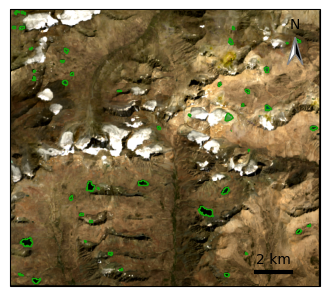

In [145]:
region_3_rio = rio.open(path_region_3)
region_3_bounds = region_3_rio.bounds
region_3_extent = [region_3_bounds.left, region_3_bounds.right, 
                   region_3_bounds.bottom, region_3_bounds.top]
fig, ax_3 = plt.subplots(figsize=(4, 4), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax_3.set_extent(region_3_extent)
imgShow(region_3_rio.read().transpose(1, 2, 0), 
                color_bands=[3,2,1], 
                per_band_clip=2, 
                extent=region_3_extent, 
                ax=ax_3)
hma_lakes_sel_smaller1_gdf.plot(ax=ax_3, facecolor='none', 
                            edgecolor="#169C0A", linewidth=1)
hma_lakes_sel_1_10_gdf.plot(ax=ax_2, facecolor='none', edgecolor="#FD0000", linewidth=1)
add_scale_bar(ax_3, loc=(0.85, 0.05), length=2)
add_north_arrow(ax_3, size=(0.05, 0.05), loc=(0.92, 0.85), font_N='10')


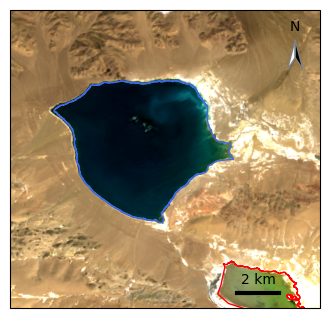

In [159]:
region_4_rio = rio.open(path_region_4)
region_4_bounds = region_4_rio.bounds
region_4_extent = [region_4_bounds.left, region_4_bounds.right, 
                   region_4_bounds.bottom, region_4_bounds.top]
fig, ax_4 = plt.subplots(figsize=(4, 4), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax_4.set_extent([83.45, 83.58, 34.01, 34.115])
imgShow(region_4_rio.read().transpose(1, 2, 0), 
                color_bands=[3,2,1], 
                per_band_clip=2, 
                extent=region_4_extent, 
                ax=ax_4)
hma_lakes_sel_larger10_gdf.plot(ax=ax_4, facecolor='none', edgecolor='#4169E1')
hma_lakes_sel_1_10_gdf.plot(ax=ax_4, facecolor='none', edgecolor="#FD0000")
hma_lakes_sel_smaller1_gdf.plot(ax=ax_4, facecolor='none', edgecolor="#169C0A")
add_scale_bar(ax_4, loc=(0.8, 0.05), length=2)
add_north_arrow(ax_4, size=(0.05, 0.05), loc=(0.92, 0.85), font_N='10')



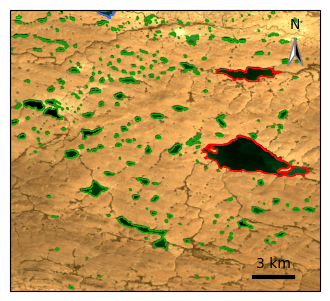

In [156]:
region_5_rio = rio.open(path_region_5)
region_5_bounds = region_5_rio.bounds
region_5_extent = [region_5_bounds.left, region_5_bounds.right, 
                   region_5_bounds.bottom, region_5_bounds.top]
fig, ax_5 = plt.subplots(figsize=(4, 4), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax_5.set_extent([86.71, 86.92, 35.51, 35.67])
imgShow(region_5_rio.read().transpose(1, 2, 0), 
                color_bands=[3,2,1], 
                per_band_clip=2, 
                extent=region_5_extent, 
                ax=ax_5)
hma_lakes_sel_larger10_gdf.plot(ax=ax_5, facecolor='none', edgecolor='#4169E1')
hma_lakes_sel_1_10_gdf.plot(ax=ax_5, facecolor='none', edgecolor="#F40707")
hma_lakes_sel_smaller1_gdf.plot(ax=ax_5, facecolor='none', edgecolor="#169C0A")
add_scale_bar(ax_5, loc=(0.85, 0.05), length=3)
add_north_arrow(ax_5, size=(0.05, 0.05), loc=(0.92, 0.85), font_N='10')


0.1